In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import load_boston

In [3]:
data = load_boston()

In [4]:
dir(data)

['DESCR', 'data', 'feature_names', 'filename', 'target']

In [5]:
df = pd.DataFrame(data.data,columns = data.feature_names)

In [6]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


In [7]:
df['target'] = data.target

In [8]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,target
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [9]:
df = df[['CRIM','RM','LSTAT','target']]

In [10]:
df.head()

,CRIM,RM,LSTAT,target
0,0.00632,6.575,4.98,24.0
1,0.02731,6.421,9.14,21.6
2,0.02729,7.185,4.03,34.7
3,0.03237,6.998,2.94,33.4
4,0.06905,7.147,5.33,36.2


In [11]:
df.describe()

,CRIM,RM,LSTAT,target
count,506.000000,506.000000,506.000000,506.000000
mean,3.613524,6.284634,12.653063,22.532806
std,8.601545,0.702617,7.141062,9.197104
min,0.006320,3.561000,1.730000,5.000000
25%,0.082045,5.885500,6.950000,17.025000
50%,0.256510,6.208500,11.360000,21.200000
75%,3.677083,6.623500,16.955000,25.000000
max,88.976200,8.780000,37.970000,50.000000


In [12]:
x = df.iloc[: , :-1]
y = df.iloc[:,-1]

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size =0.33,random_state=42)

In [15]:
x_train.shape , x_test.shape

((339, 3), (167, 3))

In [16]:
from sklearn.preprocessing import MinMaxScaler

In [17]:
sc = MinMaxScaler()

In [18]:
sc.fit(x_train)

MinMaxScaler()

In [19]:
x_train_scaled = sc.transform(x_train)
x_test_scaled = sc.transform(x_test)

In [20]:
## Sacler store max each feature

In [21]:
sc.data_max_

array([88.9762,  8.78  , 37.97  ])

In [22]:
## Scaler store min of each feature

In [23]:
sc.data_min_

array([0.00906, 3.863  , 1.73   ])

In [24]:
sc.data_range_

array([88.96714,  4.917  , 36.24   ])

In [25]:
x_train_scaled = pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled  = pd.DataFrame(x_test_scaled,columns = x_test.columns)

In [26]:
x_train_scaled.head()

,CRIM,RM,LSTAT
0,0.114918,0.472239,0.449779
1,0.007451,0.396583,0.360927
2,0.001523,0.469595,0.480684
3,0.001149,0.431157,0.320640
4,0.001337,0.531015,0.290839


In [27]:
x_train_scaled.describe()

,CRIM,RM,LSTAT
count,339.000000,339.000000,339.000000
mean,0.037567,0.501185,0.297119
std,0.086433,0.146577,0.198152
min,0.000000,0.000000,0.000000
25%,0.000821,0.412243,0.142108
50%,0.002811,0.481188,0.254967
75%,0.038088,0.578096,0.405077
max,1.000000,1.000000,1.000000


In [28]:
### Normal Data

In [29]:
np.round(x_train.describe())

,CRIM,RM,LSTAT
count,339.0,339.0,339.0
mean,3.0,6.0,12.0
std,8.0,1.0,7.0
min,0.0,4.0,2.0
25%,0.0,6.0,7.0
50%,0.0,6.0,11.0
75%,3.0,7.0,16.0
max,89.0,9.0,38.0


In [30]:
np.round(x_test.describe())

,CRIM,RM,LSTAT
count,167.0,167.0,167.0
mean,4.0,6.0,13.0
std,10.0,1.0,7.0
min,0.0,4.0,3.0
25%,0.0,6.0,7.0
50%,0.0,6.0,12.0
75%,4.0,6.0,17.0
max,74.0,9.0,37.0


In [31]:
## Scalar Data

In [32]:
np.round(x_train_scaled.describe())

,CRIM,RM,LSTAT
count,339.0,339.0,339.0
mean,0.0,1.0,0.0
std,0.0,0.0,0.0
min,0.0,0.0,0.0
25%,0.0,0.0,0.0
50%,0.0,0.0,0.0
75%,0.0,1.0,0.0
max,1.0,1.0,1.0


In [33]:
np.round(x_test_scaled.describe())

,CRIM,RM,LSTAT
count,167.0,167.0,167.0
mean,0.0,0.0,0.0
std,0.0,0.0,0.0
min,-0.0,-0.0,0.0
25%,0.0,0.0,0.0
50%,0.0,0.0,0.0
75%,0.0,1.0,0.0
max,1.0,1.0,1.0


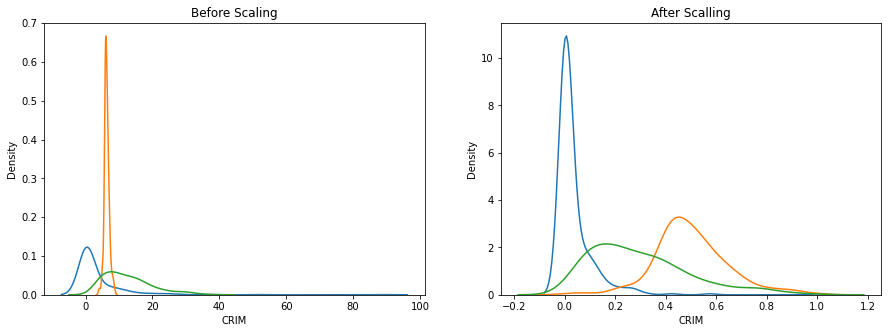

In [34]:
fig = plt.figure(figsize=(15,5))
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)

ax1.set_title('Before Scaling')
sns.kdeplot(x_train['CRIM'],ax=ax1)
sns.kdeplot(x_train['RM'],ax = ax1)
sns.kdeplot(x_train['LSTAT'],ax =ax1)

ax2.set_title('After Scalling')
sns.kdeplot(x_train_scaled['CRIM'],ax = ax2)
sns.kdeplot(x_train_scaled['RM'], ax = ax2)
sns.kdeplot(x_train_scaled['LSTAT'],ax=ax2)

plt.show()